[VideoMAEv2](https://github.com/OpenGVLab/VideoMAEv2/tree/master)

In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../../')

In [2]:
from pathlib import Path
import math
import time
import random
import numbers
import datetime
from functools import partial

import torch
from torch.nn.modules.utils import _pair

from torchvision import transforms

import numpy as np
from PIL import Image

%load_ext autoreload
%autoreload 2

from computer_vision.video_mae.finetune_parameter_parser import parser
from computer_vision.video_mae.dataset.datasets import VideoClsDataset
from computer_vision.video_mae.dataset.video_transforms import _pil_interp

In [3]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
train_annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask/trainlist01.txt'
val_annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask/vallist01.txt'

mini_train=False
if not mini_train:
    pretrain_path=Path('D:/results/ucf101/video_mae/train/checkpoints/last.pth') 
    output_dirpath=Path('D:/results/ucf101/video_mae/finetune') 
    arguments= f"""--data_root {root} --train_data_path {train_annotation_path} --val_data_path {val_annotation_path} 
    --output_dir {output_dirpath} --finetune {pretrain_path} 
    --data_set UCF101 --nb_classes 101  --batch_size 3 --input_size 224
    --short_side_size 224 --num_frames 16 --sampling_rate 4 --num_sample 2 --num_workers 0 --opt adamw
    --lr 1e-3 --drop_path 0.3 --clip_grad 5.0 --layer_decay 0.9 --opt_betas 0.9 0.999 --weight_decay 0.1
    --test_num_segment 5 --test_num_crop 3 --dist_eval
    --warmup_epochs 5 --epochs 35  --print_freq 20 --device cpu --time 12 --resume
    """ # --use-cutmix-mixup
else:
    pretrain_path=Path('D:/results/ucf101/video_mae/mini_train/checkpoints/last.pth') 
    output_dirpath=Path('D:/results/ucf101/video_mae/mini_finetune') 
    arguments= f"""--data_root {root} --train_data_path {train_annotation_path} --val_data_path {val_annotation_path} 
    --output_dir {output_dirpath}  --finetune {pretrain_path} 
    --data_set UCF101 --nb_classes 101  --batch_size 3 --input_size 224
    --short_side_size 224 --num_frames 16 --sampling_rate 4 --num_sample 2 --num_workers 0 --opt adamw
    --lr 1e-3 --drop_path 0.3 --clip_grad 5.0 --layer_decay 0.9 --opt_betas 0.9 0.999 --weight_decay 0.1
    --test_num_segment 5 --test_num_crop 3 --dist_eval 
    --warmup_epochs 5 --print_freq 20 --epochs 35  --device cpu --resume
    --n_steps 12 --n_epochs 2 --time 0.5
    """ # --use-cutmix-mixup --time 18 --resume

known_args, _=parser.parse_known_args(args=arguments.split())
if known_args.enable_deepspeed:
    parser=deepspeed.add_config_arguments(parser)
    ds_init=deepspeed.initialize
else: ds_init=None
args=parser.parse_args(arguments.split())


In [4]:
dataset_train=VideoClsDataset(data_root=args.data_root, anno_path=args.train_data_path, mode='train', clip_len=args.num_frames, 
                        frame_sample_rate=args.sampling_rate, num_segment=1, test_num_segment=args.test_num_segment,
                        test_num_crop=args.test_num_crop, num_crop=1, keep_aspect_ratio=True, crop_size=args.input_size,
                        short_side_size=args.short_side_size, new_height=256, new_width=320, args=args)
args.nb_classes=101

# dataset_val=VideoClsDataset(data_root=args.data_root, anno_path=args.val_data_path, mode='validation', clip_len=args.num_frames, 
#                         frame_sample_rate=args.sampling_rate, num_segment=1, test_num_segment=args.test_num_segment,
#                         test_num_crop=args.test_num_crop, num_crop=1, keep_aspect_ratio=True, crop_size=args.input_size,
#                         short_side_size=args.short_side_size, new_height=256, new_width=320, args=args)

# dataset_test=VideoClsDataset(data_root=args.data_root, anno_path=args.val_data_path, mode='test', clip_len=args.num_frames, 
#                         frame_sample_rate=args.sampling_rate, num_segment=1, test_num_segment=args.test_num_segment,
#                         test_num_crop=args.test_num_crop, num_crop=3, keep_aspect_ratio=True, crop_size=args.input_size,
#                         short_side_size=args.short_side_size, new_height=256, new_width=320, args=args)

type(frames_list)=<class 'list'>, len(frames_list)=2, [x.shape for x in frames_list]=[torch.Size([3, 16, 224, 224]), torch.Size([3, 16, 224, 224])]
type(label_list)=<class 'list'>, len(label_list)=2, [type(x) for x in label_list]=[<class 'int'>, <class 'int'>]
frames.shape=torch.Size([3, 16, 224, 224])
frames.shape=torch.Size([3, 16, 224, 224])


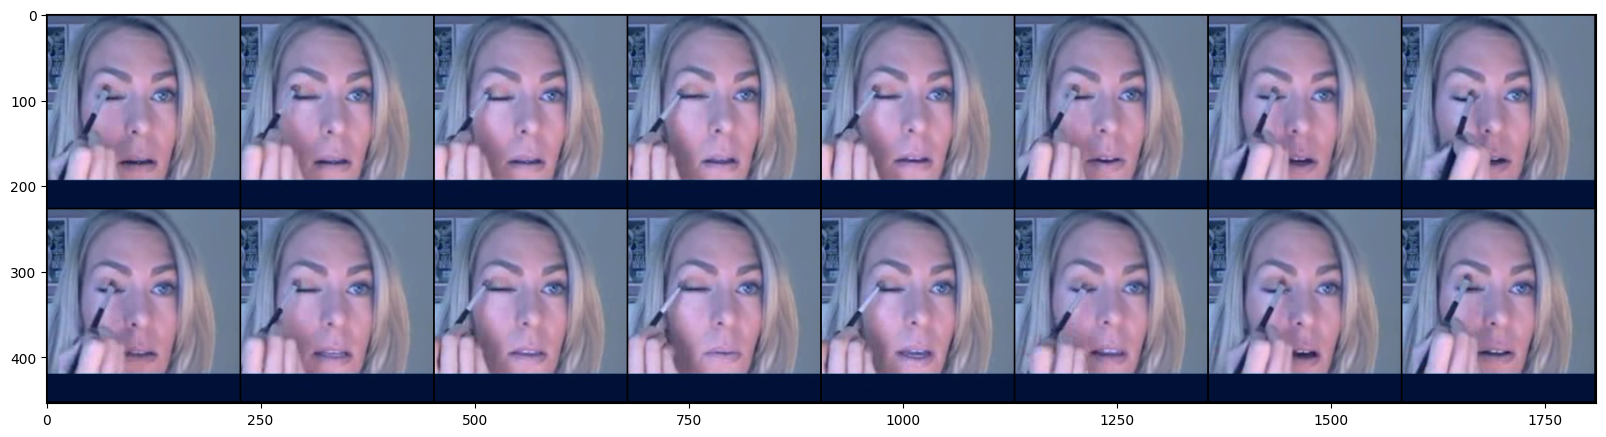

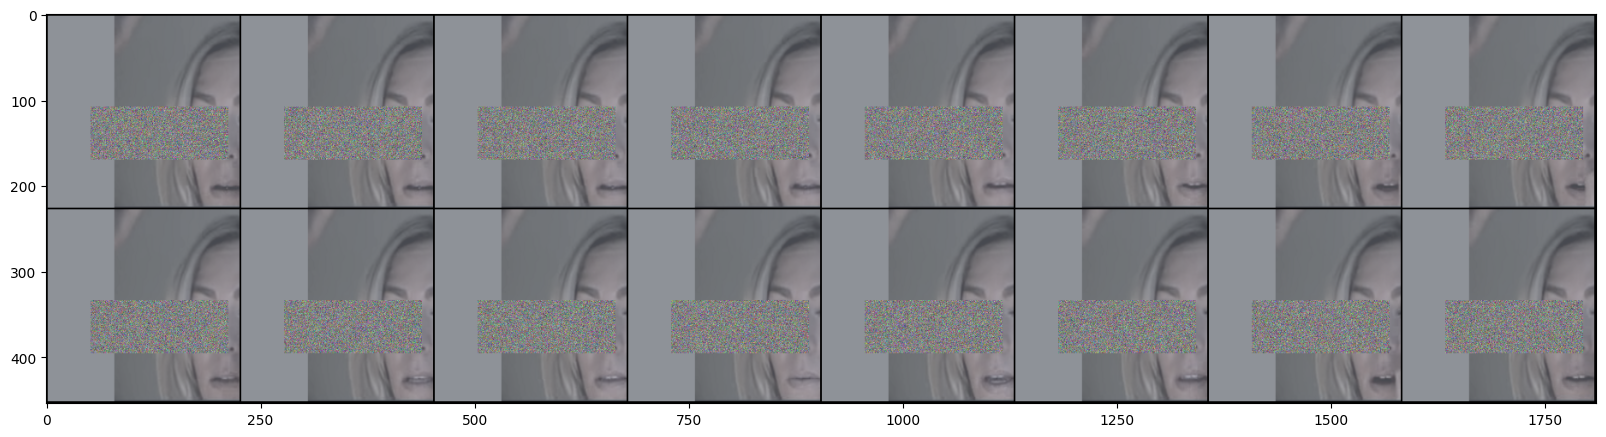

In [5]:
index=90
# def __getitem__(self, index):
if dataset_train.mode=='train': frames_list, label_list, index_list, some_set=dataset_train._get_train_item(index=index, args=dataset_train.args, 
                                                                                                            scale_t=1)
print(f"{type(frames_list)=}, {len(frames_list)=}, {[x.shape for x in frames_list]=}")
print(f"{type(label_list)=}, {len(label_list)=}, {[type(x) for x in label_list]=}")

for frames in frames_list:
    print(f"{frames.shape=}")
    plt.figure(figsize=(20,20))
    plt.imshow(make_grid(frames.permute(1,0,2,3), normalize=True).permute(1,2,0))
    

new_frames.shape=torch.Size([3, 16, 224, 224])


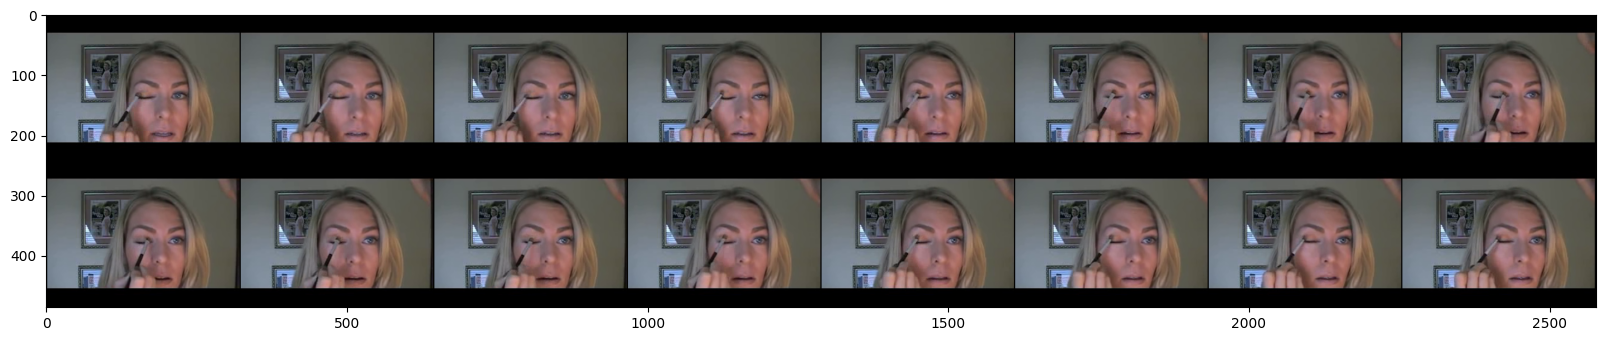

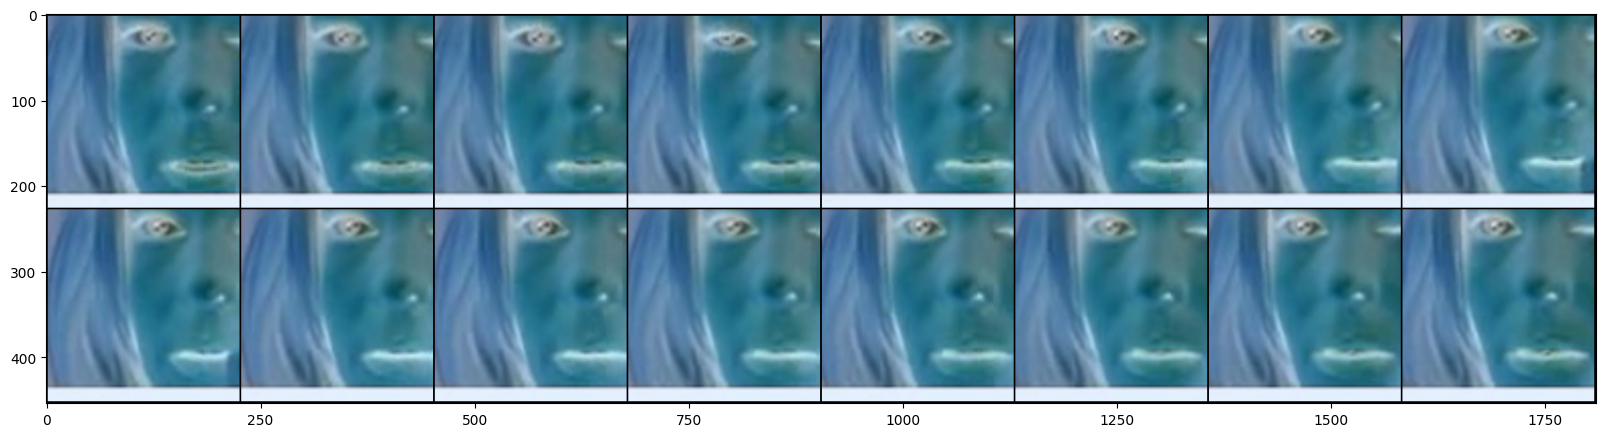

In [6]:
plt.figure(figsize=(20,20))
plt.imshow(make_grid(torch.from_numpy(buffer.transpose(0,3,1,2))).permute(1,2,0))

print(f"{new_frames.shape=}")
plt.figure(figsize=(20,20))
plt.imshow(make_grid(new_frames.permute(1,0,2,3), normalize=True).permute(1,2,0))

In [8]:
from computer_vision.video_mae.dataset.video_transforms import create_random_augment, random_short_side_scale_jitter, random_crop, \
_get_param_spatial_crop, random_resized_crop, random_resized_crop_with_shift, horizontal_flip, crop_boxes, uniform_crop
from computer_vision.video_mae.dataset.pretrained_datasets import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from computer_vision.video_mae.dataset.datasets import tensor_normalize, spatial_sampling
from computer_vision.video_mae.dataset.random_erasing import RandomErasing, _get_pixels

In [9]:
buffer.shape, type(buffer), buffer.transpose(0,3,1,2).shape, buffer.dtype

((16, 240, 320, 3), numpy.ndarray, (16, 3, 240, 320), dtype('uint8'))

In [10]:
buffer.shape, type(buffer)

((16, 240, 320, 3), numpy.ndarray)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.751672..5.0694447].


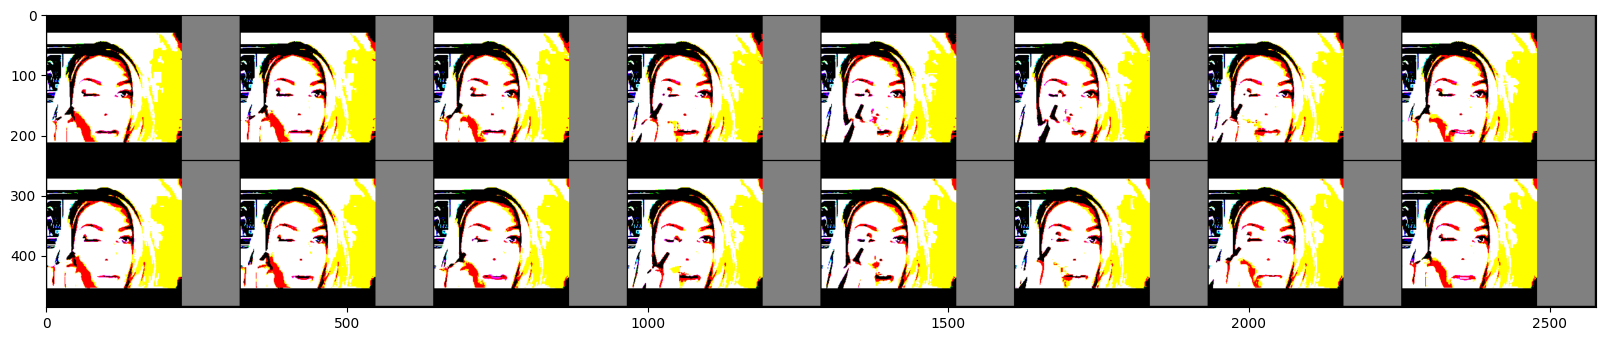

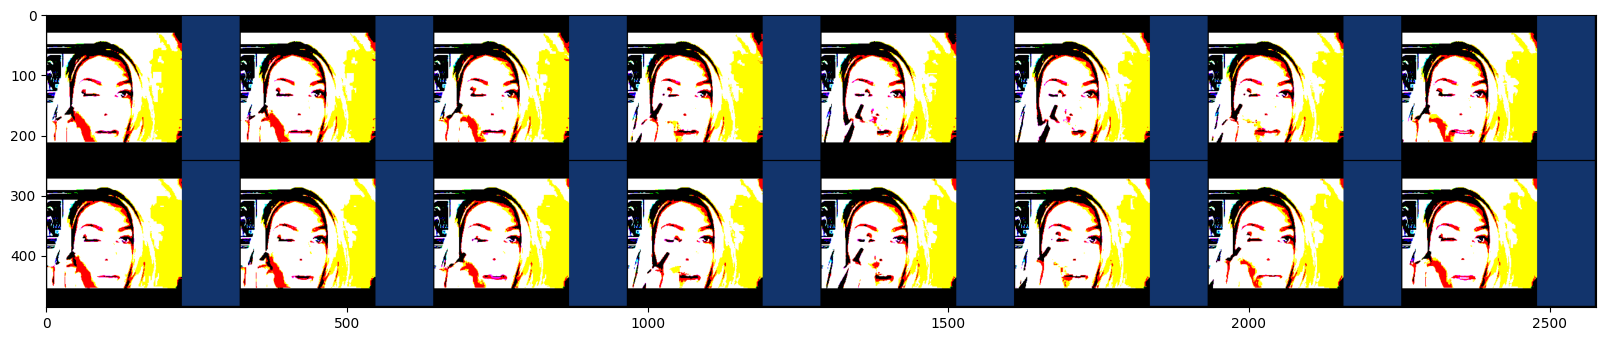

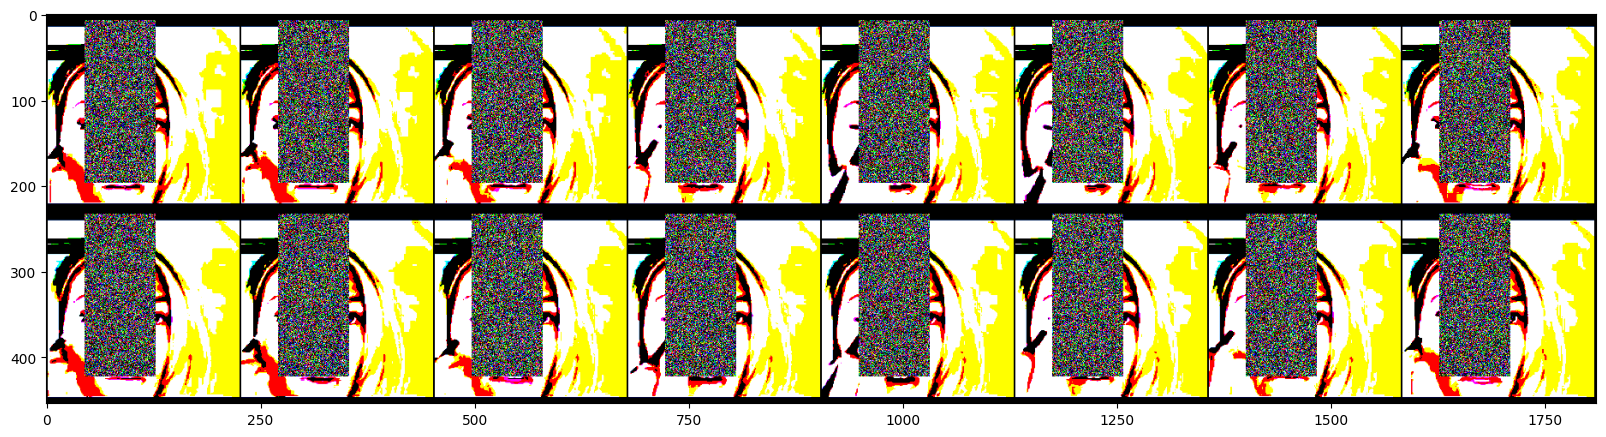

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67942464..2.6400003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.527762..4.7151184].


input.shape=torch.Size([16, 3, 224, 224])


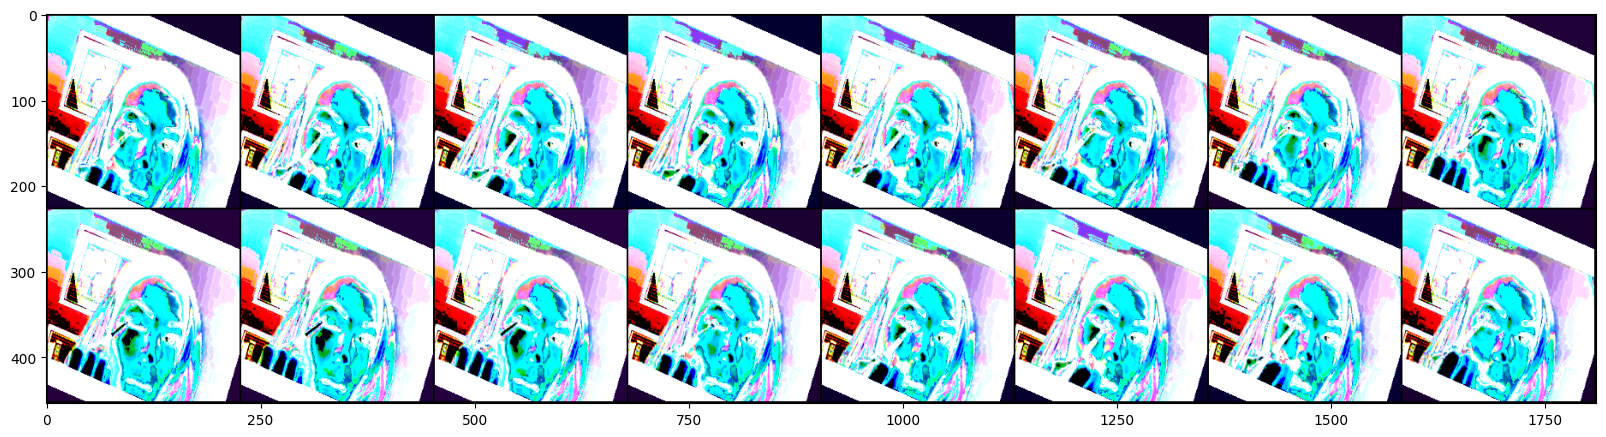

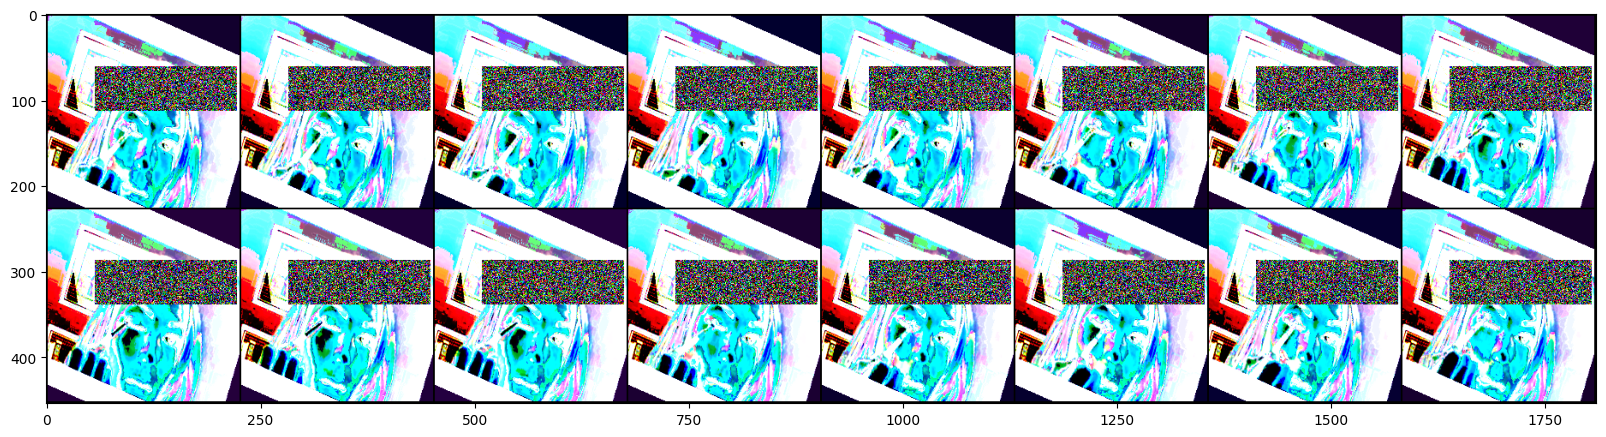

In [13]:
plt.figure(figsize=(20,20))
plt.imshow(make_grid(input).permute(1,2,0))

erase_transform.probability=1.
batch_size=input.shape[0]
# skip first slice of batch if num_splits is set (for clean portion of samples)
batch_start=batch_size//erase_transform.num_splits if erase_transform.num_splits>1 else 0
erase_transform._erase_cube(input, batch_start)

plt.figure(figsize=(20,20))
plt.imshow(make_grid(input).permute(1,2,0))
print(f"{input.shape=}", flush=True)

In [14]:
erase_transform.per_pixel, erase_transform.rand_color

(True, False)

1.2787593157922534

In [16]:
math.exp(np.random.uniform(*log_ratio))

1.0780748591496783

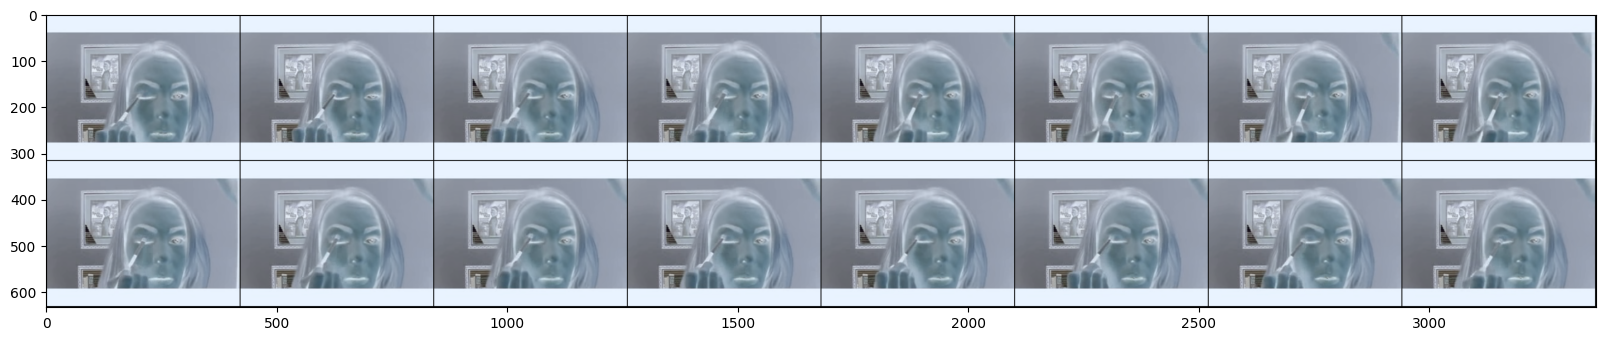

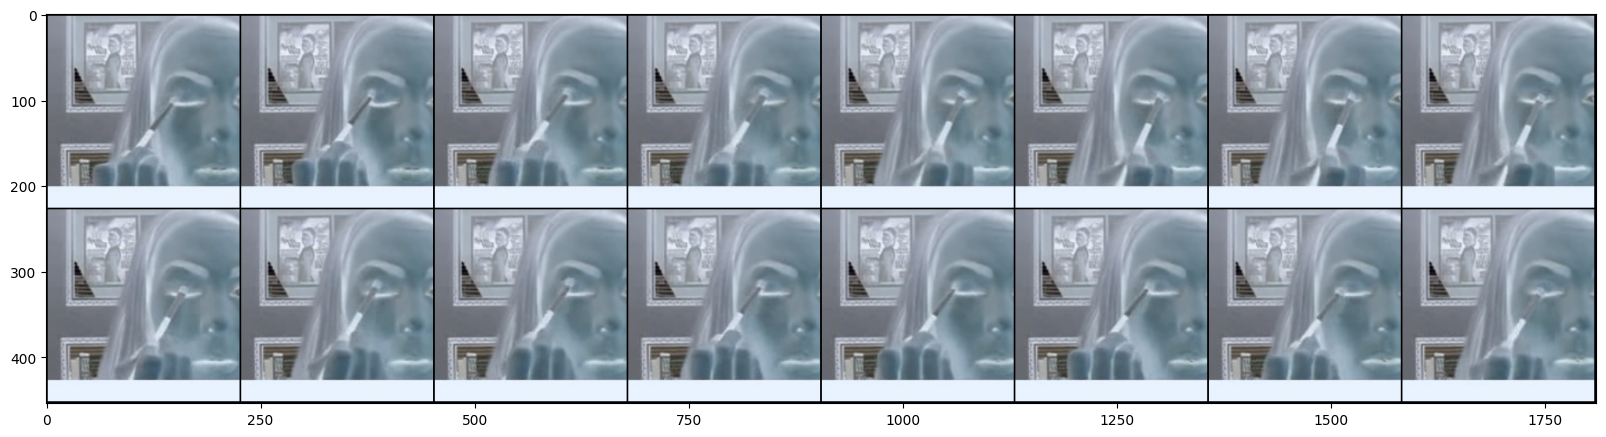

In [12]:
outs,_=random_short_side_scale_jitter(images=frames.clone(), min_size=min_scale, max_size=max_scale, boxes=None, 
                                                inverse_uniform_sampling=inverse_uniform_sampling)
plt.figure(figsize=(20,20))
plt.imshow(make_grid(outs,normalize=True).permute(1,2,0))

outs, _=random_crop(outs, crop_size)
plt.figure(figsize=(20,20))
plt.imshow(make_grid(outs,normalize=True).permute(1,2,0))
